In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("auto-mpg.csv")
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1
...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790.0,15.6,82,1
394,44.0,4,97.0,52.0,2130.0,24.6,82,2
395,32.0,4,135.0,84.0,2295.0,11.6,82,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 25.0 KB


In [4]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [5]:
df=pd.get_dummies(df,columns=["origin"])
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_1,origin_2,origin_3
0,18.0,8,307.0,130.0,3504.0,12.0,70,True,False,False
1,15.0,8,350.0,165.0,3693.0,11.5,70,True,False,False
2,18.0,8,318.0,150.0,3436.0,11.0,70,True,False,False
3,16.0,8,304.0,150.0,3433.0,12.0,70,True,False,False
4,17.0,8,302.0,140.0,3449.0,10.5,70,True,False,False
...,...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790.0,15.6,82,True,False,False
394,44.0,4,97.0,52.0,2130.0,24.6,82,False,True,False
395,32.0,4,135.0,84.0,2295.0,11.6,82,True,False,False
396,28.0,4,120.0,79.0,2625.0,18.6,82,True,False,False


In [8]:
from sklearn.model_selection import train_test_split

In [9]:
x=df.loc[:,df.columns!='mpg']

In [10]:
y=df["mpg"]

In [11]:
x_train,x_test,y_train,y_test =train_test_split(x,y,test_size=0.2,random_state=42)

In [12]:
x_train.head()

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_1,origin_2,origin_3
3,8,304.0,150.0,3433.0,12.0,70,True,False,False
18,4,97.0,88.0,2130.0,14.5,70,False,False,True
376,4,91.0,68.0,2025.0,18.2,82,False,False,True
248,4,91.0,60.0,1800.0,16.4,78,False,False,True
177,4,115.0,95.0,2694.0,15.0,75,False,True,False


In [13]:
y_train.head()

3      16.0
18     27.0
376    37.0
248    36.1
177    23.0
Name: mpg, dtype: float64

In [15]:
from sklearn.preprocessing import StandardScaler

In [16]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.fit_transform(x_test)

In [18]:
df_scaled=pd.DataFrame(x_train_scaled)

In [21]:
numerical_columns=df_scaled.select_dtypes(include=['int64','float64'])
numerical_columns

,0,1,2,3,4,5,6,7,8
0,1.527188,1.090196,1.252385,0.552826,-1.319334,-1.696667,0.788954,-0.462321,-0.511766
1,-0.850515,-0.922996,-0.409753,-0.999667,-0.413182,-1.696667,-1.267500,-0.462321,1.954017
2,-0.850515,-0.981350,-0.945926,-1.124772,0.927922,1.638975,-1.267500,-0.462321,1.954017
3,-0.850515,-0.981350,-1.160396,-1.392854,0.275493,0.527094,-1.267500,-0.462321,1.954017
4,-0.850515,-0.747936,-0.222092,-0.327675,-0.231952,-0.306816,-1.267500,2.163001,-0.511766
...,...,...,...,...,...,...,...,...,...
313,-1.444941,-1.185587,-0.168475,-0.761372,-0.775643,-1.140727,-1.267500,-0.462321,1.954017
314,1.527188,1.537573,2.056645,1.822940,-1.138103,-0.862757,0.788954,-0.462321,-0.511766
315,-0.850515,-0.563150,-0.222092,-0.540949,-0.304444,0.527094,-1.267500,-0.462321,1.954017
316,-0.850515,-1.000801,-1.106778,-1.094985,0.601707,1.361005,-1.267500,-0.462321,1.954017


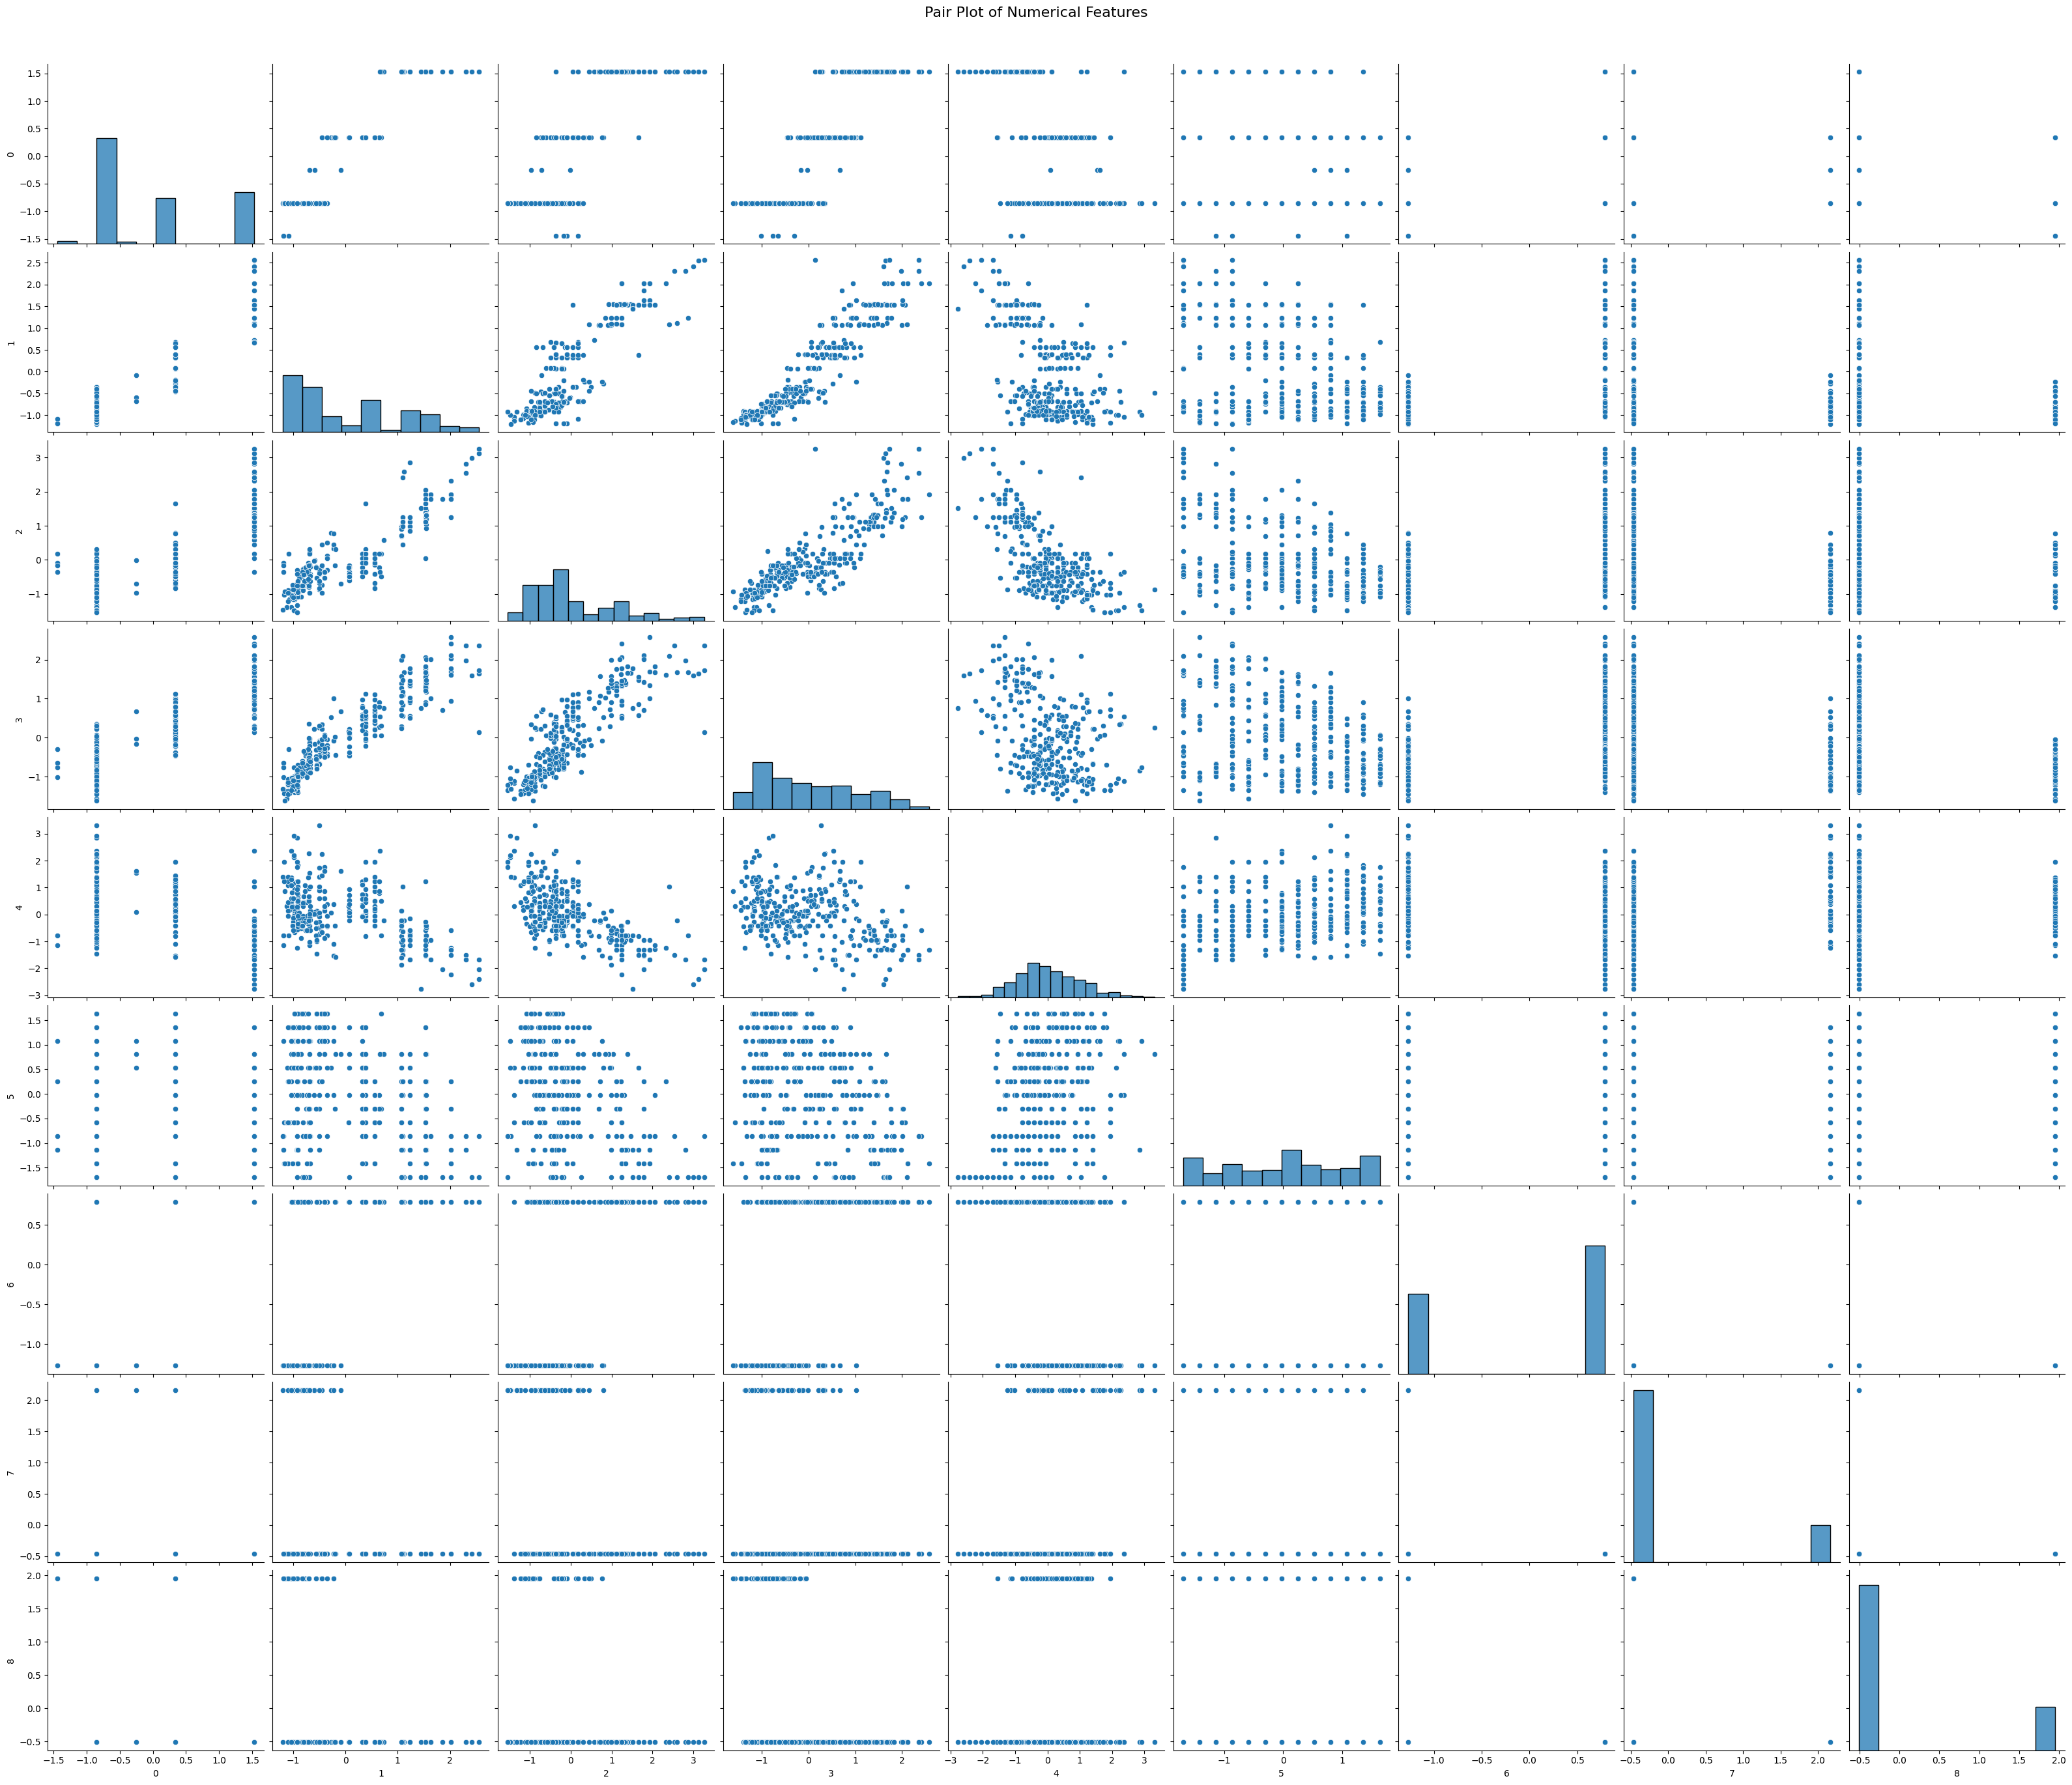

In [58]:
pairplot = sns.pairplot(numerical_columns, height=3, aspect=1.2)
plt.suptitle("Pair Plot of Numerical Features", fontsize=16, y=1.02)
plt.show()

In [28]:
pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, Input
from tensorflow.keras.optimizers import Adam

In [36]:
model = Sequential([
    Input(shape=(x_train_scaled.shape[1],)), 
    Dense(64, activation='relu'), 
    Dense(32, activation='relu'), 
    Dense(1)  
])

In [37]:
model.compile(optimizer='adam',loss='mse', metrics=['mae'])

In [39]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [40]:
history = model.fit(x_train_scaled, y_train, epochs=100, validation_data=(x_test_scaled, y_test), callbacks=[early_stopping])

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 658.8771 - mae: 24.2909 - val_loss: 587.6289 - val_mae: 23.1055
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 622.3922 - mae: 23.6529 - val_loss: 585.8224 - val_mae: 23.0663
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 609.3251 - mae: 23.4714 - val_loss: 583.9379 - val_mae: 23.0255
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 608.4056 - mae: 23.3817 - val_loss: 581.9426 - val_mae: 22.9821
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 614.3287 - mae: 23.4222 - val_loss: 579.8163 - val_mae: 22.9358
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 616.8711 - mae: 23.5943 - val_loss: 577.5261 - val_mae: 22.8858
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 634.4713 - mae: 23.8969 - val_loss: 575.0540 - val_mae: 22.8317
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 603.8127 - mae: 23.2138 - val_loss: 572.4071 - val_mae: 22.7737
Epoch 9/100
10/

In [41]:
loss, mae = model.evaluate(x_test_scaled, y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 75.0247 - mae: 6.8669


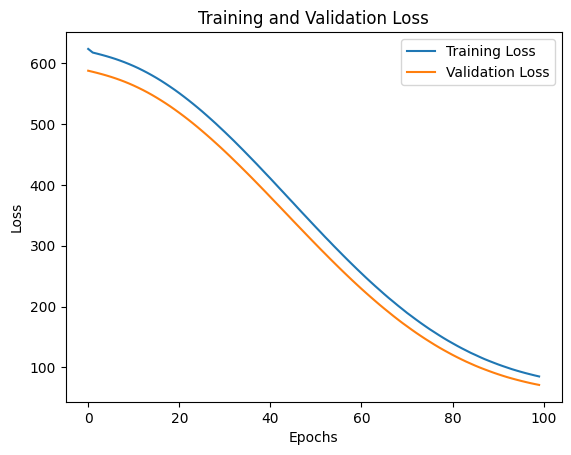

In [42]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [43]:
if mae <= 2:
    print("The model predicts MPG with an average error of ±2 MPG, which is sufficient for real-world applications.")
else:
    print("The model's error is higher than the acceptable limit for real-world applications.")


The model's error is higher than the acceptable limit for real-world applications.


Bonus Task

In [44]:
def build_model(units=64, dropout_rate=0.2, learning_rate=0.001):
    model = Sequential([
        Input(shape=(x_train_scaled.shape[1],)),  
        Dense(units, activation='relu'), 
        Dropout(dropout_rate), 
        Dense(32, activation='relu'), 
        Dense(1) 
    ])
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer,
                  loss='mse',
                  metrics=['mae'])
    return model

In [45]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [46]:
best_units = 128
best_dropout = 0.3
best_lr = 0.001

In [47]:
model = build_model(units=best_units, dropout_rate=best_dropout, learning_rate=best_lr)
history = model.fit(x_train_scaled, y_train, epochs=100, validation_data=(x_test_scaled, y_test), callbacks=[early_stopping], verbose=0)

In [49]:
loss, mae = model.evaluate(x_test_scaled, y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 111.3782 - mae: 8.3291


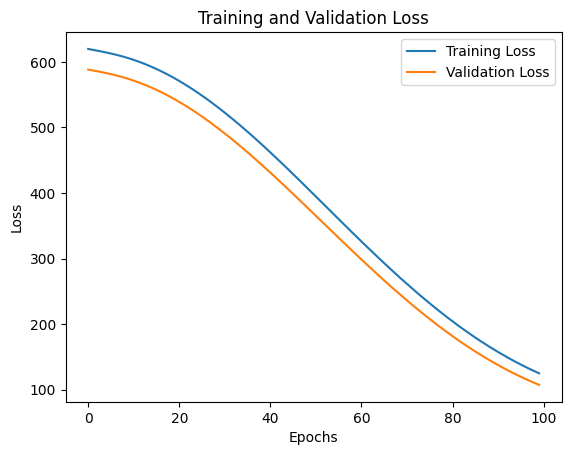

In [50]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [51]:
if mae <= 2:
    print("The model predicts MPG with an average error of ±2 MPG, which is sufficient for real-world applications.")
else:
    print("The model's error is higher than the acceptable limit for real-world applications.")


The model's error is higher than the acceptable limit for real-world applications.


The model performance shows a gradual decrease in both loss and mean absolute error (MAE) over the epochs, which indicates that the model is learning and improving. Here's a summary:

Initial Phase (Epochs 1-10):

High loss and MAE, suggesting the model is adapting to the data.
Loss: 658.88 → 577.77
MAE: 24.29 → 22.83
Middle Phase (Epochs 11-30):

Steady improvement with loss and MAE decreasing consistently.
Loss: 563.18 → 462.03
MAE: 22.57 → 20.20
Final Phase (Epochs 31-36+):

The model continues to improve with diminishing returns, suggesting convergence.
Loss: 455.03 → 418.47
MAE: 20.03 → 19.10